In [ ]:

!pip install qiskit

!pip install matplotlib pylatexenc

!pip install numpy

!pip install qiskit-aer

Bloch Sphere BEFORE teleportation (q0 holds the secret):


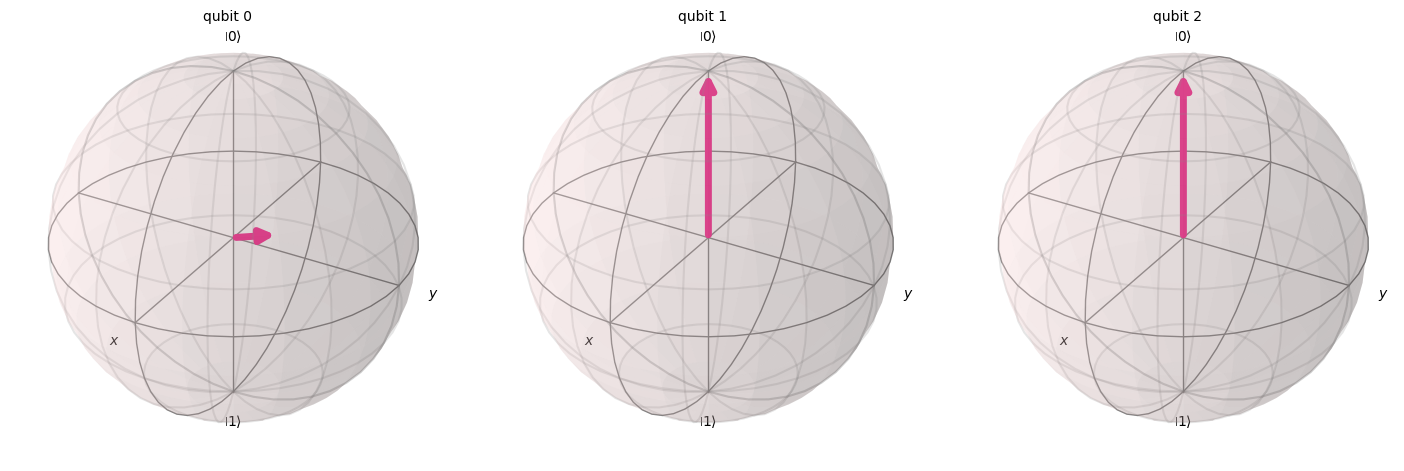

Bloch Sphere AFTER teleportation (q2 should match q0):


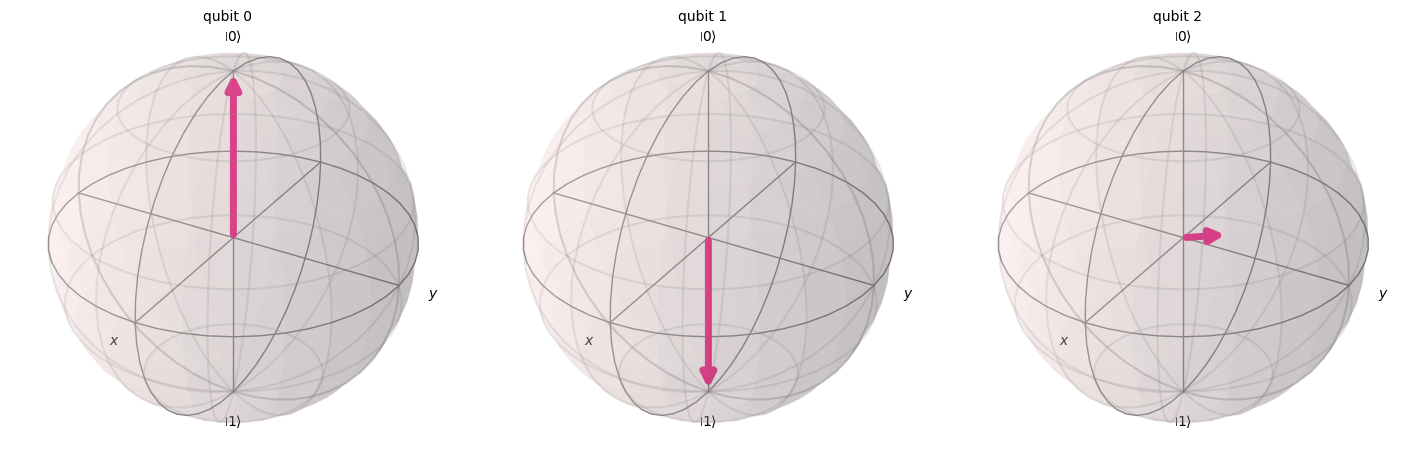

Quantum Teleportation Circuit:


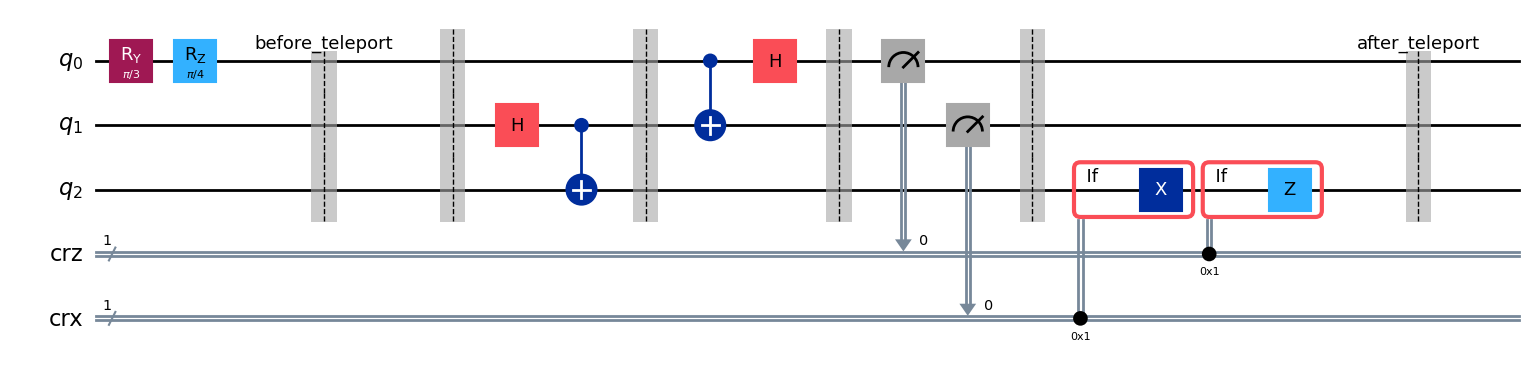

In [ ]:



from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_bloch_multivector
from qiskit_aer import AerSimulator

import numpy as np
import matplotlib.pyplot as plt


qr = QuantumRegister(3, name="q")
crz = ClassicalRegister(1, name="crz")
crx = ClassicalRegister(1, name="crx")

qc = QuantumCircuit(qr, crz, crx)


theta = np.pi / 3
phi = np.pi / 4
qc.ry(theta, 0)
qc.rz(phi, 0)


qc.save_statevector(label="before_teleport")


qc.barrier()
qc.h(1)
qc.cx(1, 2)


qc.barrier()
qc.cx(0, 1)
qc.h(0)


qc.barrier()
qc.measure(0, crz)
qc.measure(1, crx)


qc.barrier()

with qc.if_test((crx, 1)):
    qc.x(2)

with qc.if_test((crz, 1)):
    qc.z(2)


qc.save_statevector(label="after_teleport")


simulator = AerSimulator()
job = simulator.run(qc)
result = job.result()


state_before = result.data(0)["before_teleport"]
state_after = result.data(0)["after_teleport"]


print("Bloch Sphere BEFORE teleportation (q0 holds the secret):")
display(plot_bloch_multivector(state_before))

print("Bloch Sphere AFTER teleportation (q2 should match q0):")
display(plot_bloch_multivector(state_after))


print("Quantum Teleportation Circuit:")
qc.draw("mpl")